## 1 Importing nesscary librries and packgaes

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.facecolor': 'white'})





## 2 Data preprossing

In [110]:
df = pd.read_csv(r'/content/all_egypt_hotels.csv')

df.head()

,city,hotel_name,price,currency,num_adults,num_children,num_nights,rating,reviews_count,location,distance_from_center,star_rating,property_type,room_type,free_cancellation,meal_plan,amenities,hotel_url,scraped_date
0,Cairo,Regant pyramids hotel,715,EGP,2,0,1,10.0,1.0,"Giza, Cairo",11.3 km from downtown,4.0,Hotel,Double Room,Yes,Breakfast included,"Hot tub/Jacuzzi, Spa, Bar",https://www.booking.com/hotel/eg/regant-pyrami...,5/9/2026
1,Cairo,Sky-lounge,3606,EGP,2,0,1,NaN,NaN,"Maadi, Cairo",10.2 km from downtown,NaN,Apartment,Three-Bedroom Apartment,No,NaN,Free parking,https://www.booking.com/hotel/eg/sky-lounge.ht...,5/9/2026
2,Cairo,Hilton Cairo Grand Nile,5377,EGP,2,0,1,8.0,12311.0,Cairo,1.4 km from downtown,5.0,Hotel,Twin Guest room with Nile View,Yes,NaN,"Hot tub/Jacuzzi, Spa",https://www.booking.com/hotel/eg/grand-nile-to...,5/9/2026
3,Cairo,Agor-Cairo Hotel Downtown,7908,EGP,2,0,1,10.0,7.0,Cairo,0.8 km from downtown,4.0,Hotel,Deluxe Double or Twin Room with City View,Yes,Breakfast included,"Hot tub/Jacuzzi, Spa, Bar",https://www.booking.com/hotel/eg/agor-cairo-do...,5/9/2026
4,Cairo,gold cairo downtown,5272,EGP,2,0,1,NaN,NaN,Cairo,100 m from downtown,4.0,Hotel,Double Room,Yes,Breakfast included,"Hot tub/Jacuzzi, Spa, Bar",https://www.booking.com/hotel/eg/gold-cairo-do...,5/9/2026


In [111]:
df.shape

(1040, 19)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  1040 non-null   object 
 1   hotel_name            1040 non-null   object 
 2   price                 1040 non-null   int64  
 3   currency              1040 non-null   object 
 4   num_adults            1040 non-null   int64  
 5   num_children          1040 non-null   int64  
 6   num_nights            1040 non-null   int64  
 7   rating                945 non-null    float64
 8   reviews_count         945 non-null    float64
 9   location              1040 non-null   object 
 10  distance_from_center  882 non-null    object 
 11  star_rating           748 non-null    float64
 12  property_type         1040 non-null   object 
 13  room_type             1040 non-null   object 
 14  free_cancellation     1040 non-null   object 
 15  meal_plan            

In [113]:
df.describe()

,price,num_adults,num_children,num_nights,rating,reviews_count,star_rating
count,1040.000000,1040.0,1040.0,1040.0,945.000000,945.000000,748.000000
mean,5378.347115,2.0,0.0,1.0,8.454603,715.697354,3.883690
std,15768.816913,0.0,0.0,0.0,1.146033,1381.203197,0.838243
min,264.000000,2.0,0.0,1.0,1.000000,1.000000,1.000000
25%,1845.000000,2.0,0.0,1.0,8.000000,26.000000,3.000000
50%,3427.000000,2.0,0.0,1.0,8.600000,151.000000,4.000000
75%,6140.000000,2.0,0.0,1.0,9.200000,778.000000,5.000000
max,474480.000000,2.0,0.0,1.0,10.000000,13240.000000,5.000000


In [114]:
df.isnull().sum()


,0
city,0
hotel_name,0
price,0
currency,0
num_adults,0
num_children,0
num_nights,0
rating,95
reviews_count,95
location,0


In [115]:
df.duplicated().sum()


np.int64(0)

In [116]:
df.drop(columns=['hotel_url', 'scraped_date', 'currency'], inplace=True)


In [117]:
def clean_distance(value):
    value = str(value).lower().strip()
    if 'km' in value:
        return float(value.split('km')[0].strip())
    elif 'm' in value:
        meters = float(value.split('m')[0].strip())
        return meters / 1000
    return np.nan

df['distance_from_center'] = df['distance_from_center'].apply(clean_distance)


In [118]:
print(df['free_cancellation'].value_counts())
df['free_cancellation'] = df['free_cancellation'].map({'Yes': 1, 'No': 0})

free_cancellation
Yes    590
No     450
Name: count, dtype: int64


In [119]:
df['meal_plan']            = df['meal_plan'].fillna('Room Only')
df['rating']               = df['rating'].fillna(df['rating'].median())
df['reviews_count']        = df['reviews_count'].fillna(df['reviews_count'].median())
df['star_rating']          = df['star_rating'].fillna(df['star_rating'].median())
df['distance_from_center'] = df['distance_from_center'].fillna(df['distance_from_center'].median())

In [120]:
df['amenities'].unique()

array(['Hot tub/Jacuzzi, Spa, Bar', 'Free parking',
       'Hot tub/Jacuzzi, Spa', 'Hot tub/Jacuzzi, Free parking, Spa',
       'Heated pool, Bar', 'Hot tub/Jacuzzi, Airport shuttle (free)',
       'Airport shuttle (free), Bar, Restaurant',
       'Restaurant, 24-hour front desk', 'Free Wifi',
       'Free parking, Airport shuttle (free), Bar',
       'Free Wifi, 24-hour front desk', 'Spa, Bar',
       'Restaurant, Free Wifi, 24-hour front desk',
       'Adults only, Bar, Restaurant', 'Hot tub/Jacuzzi, Heated pool',
       'Bar, Restaurant, Free Wifi', 'Heated pool, Bar, Restaurant',
       'Spa, Bar, Restaurant', 'Hot tub/Jacuzzi, Heated pool, Spa',
       'Airport shuttle (free), Restaurant, Free Wifi',
       'Adults only, Free Wifi, 24-hour front desk',
       'Hot tub/Jacuzzi, Heated pool, Airport shuttle (free)',
       'Heated pool, Spa, Bar', 'Heated pool, Spa',
       'Heated pool, Free parking, Bar',
       'Free parking, Free Wifi, 24-hour front desk',
       'Hot tub/Jacuzz

In [121]:
df['amenities'].value_counts().head(10)

,count
amenities,
"Free parking, Bar, Restaurant",62
"Free parking, Restaurant, Free Wifi",49
"Free parking, Free Wifi",47
Free Wifi,35
"Free Wifi, 24-hour front desk",29
Free parking,29
"Free parking, Free Wifi, 24-hour front desk",27
"Hot tub/Jacuzzi, Heated pool, Free parking",23
"Free parking, Bar, Free Wifi",23


In [122]:
df['amenities_missing'] = df['amenities'].isna().astype(int)

df['has_wifi'] = df['amenities'].str.contains('Free Wifi', na=False).astype(int)
df['has_spa'] = df['amenities'].str.contains('Spa', na=False).astype(int)
df['has_parking'] = df['amenities'].str.contains('Free parking', na=False).astype(int)
df['has_restaurant'] = df['amenities'].str.contains('Restaurant', na=False).astype(int)
df['has_bar'] = df['amenities'].str.contains('Bar', na=False).astype(int)
df['has_pool'] = df['amenities'].str.contains('Heated pool', na=False).astype(int)
df['has_jacuzzi'] = df['amenities'].str.contains('Hot tub/Jacuzzi', na=False).astype(int)

In [123]:
df.drop(columns=['amenities'], inplace=True)

In [124]:
df.isnull().sum()

,0
city,0
hotel_name,0
price,0
num_adults,0
num_children,0
num_nights,0
rating,0
reviews_count,0
location,0
distance_from_center,0


In [125]:
df.describe()

,price,num_adults,num_children,num_nights,rating,reviews_count,distance_from_center,star_rating,free_cancellation,amenities_missing,has_wifi,has_spa,has_parking,has_restaurant,has_bar,has_pool,has_jacuzzi
count,1040.000000,1040.0,1040.0,1040.0,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000
mean,5378.347115,2.0,0.0,1.0,8.467885,664.114423,8.288673,3.916346,0.567308,0.363462,0.274038,0.093269,0.397115,0.239423,0.200962,0.090385,0.140385
std,15768.816913,0.0,0.0,0.0,1.093188,1326.568836,10.341291,0.712680,0.495687,0.481228,0.446243,0.290949,0.489536,0.426937,0.400912,0.286870,0.347553
min,264.000000,2.0,0.0,1.0,1.000000,1.000000,0.020000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1845.000000,2.0,0.0,1.0,8.000000,35.750000,1.700000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3427.000000,2.0,0.0,1.0,8.600000,151.000000,4.700000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6140.000000,2.0,0.0,1.0,9.100000,667.500000,10.300000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,474480.000000,2.0,0.0,1.0,10.000000,13240.000000,80.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [126]:

print("Before cleaning:")
print("Min:", df['price'].min())
print("Max:", df['price'].max())
print("Mean:", df['price'].mean())


low = df['price'].quantile(0.01)
high = df['price'].quantile(0.80)

df = df[(df['price'] >= low) & (df['price'] <= high)]

print("\nAfter cleaning:")
print("Min:", df['price'].min())
print("Max:", df['price'].max())
print("Mean:", df['price'].mean())


Before cleaning:
Min: 264
Max: 474480
Mean: 5378.347115384616

After cleaning:
Min: 580
Max: 6992
Mean: 3077.278928136419


In [127]:
df

,city,hotel_name,price,num_adults,num_children,num_nights,rating,reviews_count,location,distance_from_center,...,free_cancellation,meal_plan,amenities_missing,has_wifi,has_spa,has_parking,has_restaurant,has_bar,has_pool,has_jacuzzi
0,Cairo,Regant pyramids hotel,715,2,0,1,10.0,1.0,"Giza, Cairo",11.3,...,1,Breakfast included,0,0,1,0,0,1,0,1
1,Cairo,Sky-lounge,3606,2,0,1,8.6,151.0,"Maadi, Cairo",10.2,...,0,Room Only,0,0,0,1,0,0,0,0
2,Cairo,Hilton Cairo Grand Nile,5377,2,0,1,8.0,12311.0,Cairo,1.4,...,1,Room Only,0,0,1,0,0,0,0,1
4,Cairo,gold cairo downtown,5272,2,0,1,8.6,151.0,Cairo,0.1,...,1,Breakfast included,0,0,1,0,0,1,0,1
5,Cairo,cairoooo houb,2900,2,0,1,8.6,151.0,Cairo,0.2,...,1,Breakfast included,0,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,Al Minya,Furnished apartment in Minya with archaeologic...,2715,2,0,1,5.7,3.0,Minya,3.3,...,0,Room Only,1,0,0,0,0,0,0,0
1036,Al Minya,Countryside House,3585,2,0,1,8.6,151.0,Minya,30.7,...,1,Breakfast included,1,0,0,0,0,0,0,0
1037,Al Minya,Grand Aton,4745,2,0,1,6.1,21.0,Al Ikhşāş,2.0,...,1,Breakfast included,1,0,0,0,0,0,0,0
1038,Al Minya,Holy Family Hotel,5124,2,0,1,8.5,32.0,Jabal aţ Ţayr,20.4,...,0,Room Only,1,0,0,0,0,0,0,0


## 3  Data Analysis visualization


### 3.1 Price Distribution

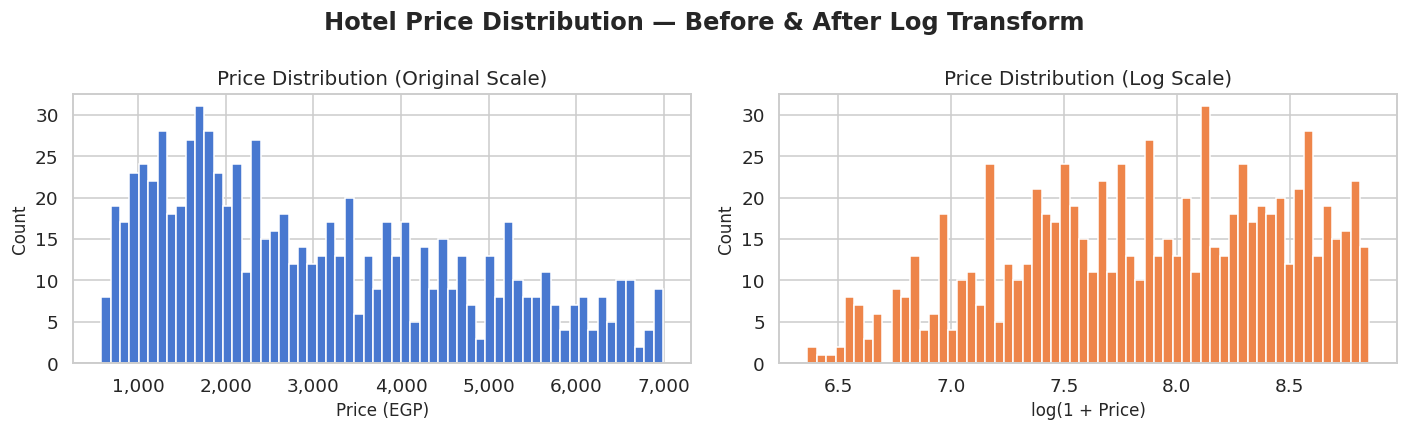

Original  — Skewness: 0.54  |  Median: 2,662 EGP  |  Mean: 3,077 EGP
Log-scale — Skewness: -0.29


In [128]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=60, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Price Distribution (Original Scale)')
axes[0].set_xlabel('Price (EGP)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].hist(np.log1p(df['price']), bins=60, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Hotel Price Distribution — Before & After Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original  — Skewness: {df['price'].skew():.2f}  |  Median: {df['price'].median():,.0f} EGP  |  Mean: {df['price'].mean():,.0f} EGP")
print(f"Log-scale — Skewness: {np.log1p(df['price']).skew():.2f}")

### 3.2 Price by City

/tmp/ipykernel_3289/971756306.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_stats.index, y=city_stats.values, palette='coolwarm_r', ax=ax)


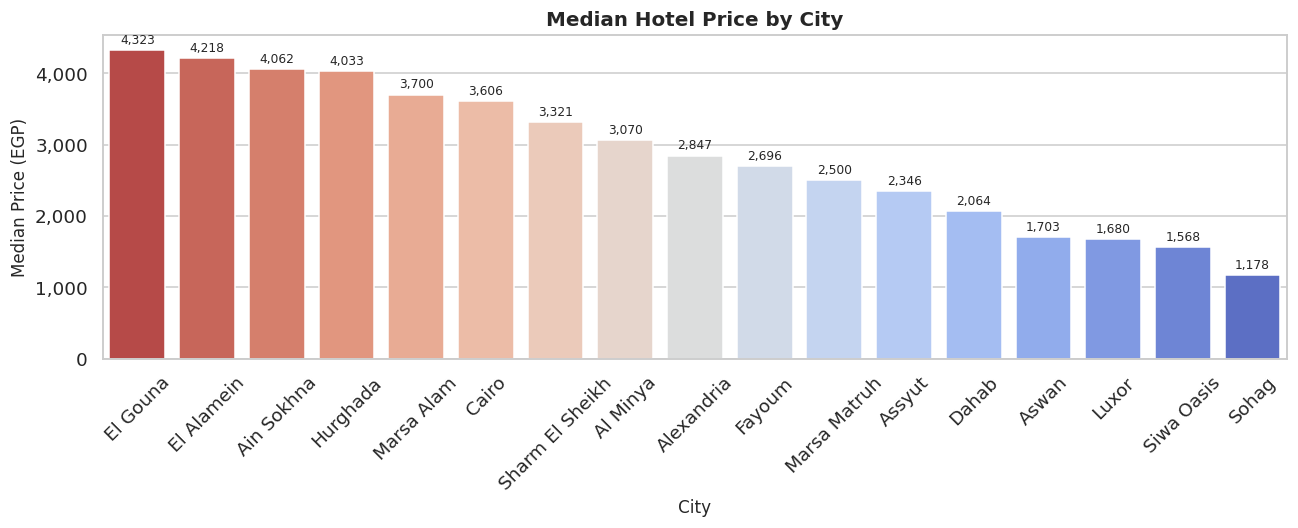

Top 3 most expensive cities (median):
city
El Gouna      4,323 EGP
El Alamein    4,218 EGP
Ain Sokhna    4,062 EGP
Name: price, dtype: object


In [129]:
city_stats = df.groupby('city')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=city_stats.index, y=city_stats.values, palette='coolwarm_r', ax=ax)
ax.set_title('Median Hotel Price by City', fontsize=13, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Median Price (EGP)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(city_stats.values):
    ax.text(i, v + 50, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("Top 3 most expensive cities (median):")
print(city_stats.head(3).apply(lambda x: f"{x:,.0f} EGP"))

> **Insight:** Red Sea coastal destinations (Hurghada, Sharm El Sheikh, El Gouna) command significantly higher prices than Upper Egypt cities (Luxor, Aswan, Asyut). This reflects the dominance of resort-style tourism in coastal Egypt versus heritage/budget tourism inland.

### 3.3 Price by Property Type

/tmp/ipykernel_3289/1034295949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='property_type', x='price', order=order,


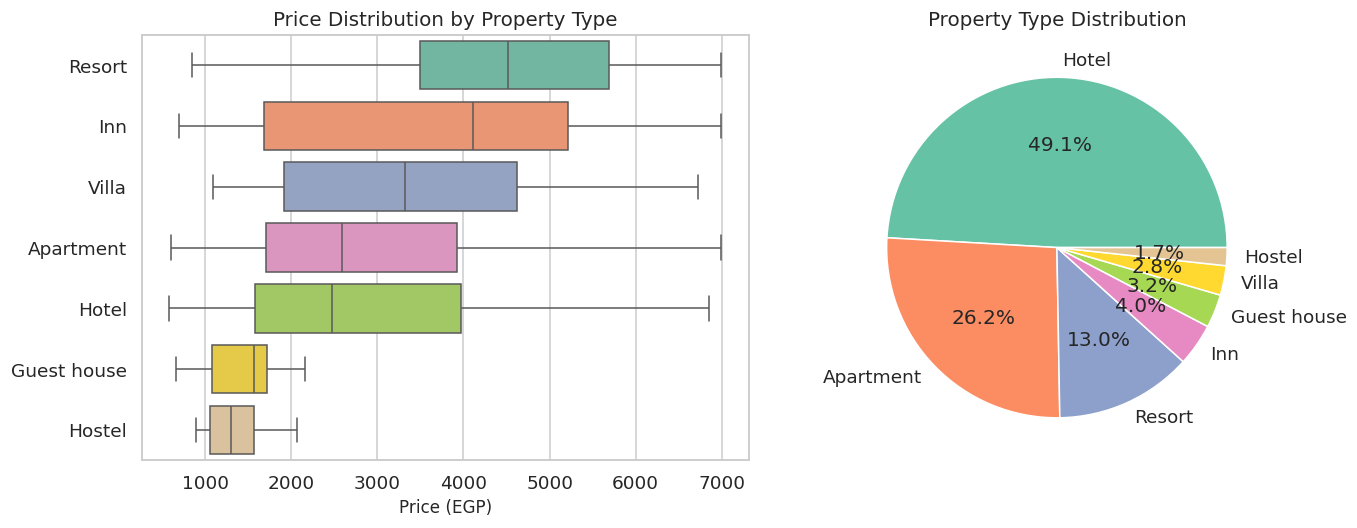

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = df.groupby('property_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='property_type', x='price', order=order,
            palette='Set2', ax=axes[0], showfliers=False)
axes[0].set_title('Price Distribution by Property Type')
axes[0].set_xlabel('Price (EGP)')
axes[0].set_ylabel('')

prop_counts = df['property_type'].value_counts()
axes[1].pie(prop_counts.values, labels=prop_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Property Type Distribution')

plt.tight_layout()
plt.show()

> **Insight:** Resorts and Hotels sit at the top of the price range, while Hostels and Guest Houses occupy the budget segment. Villas show the widest price variance, reflecting luxury private rentals mixed with modest offerings.

### 3.4 Rating Distribution & Price Relationship

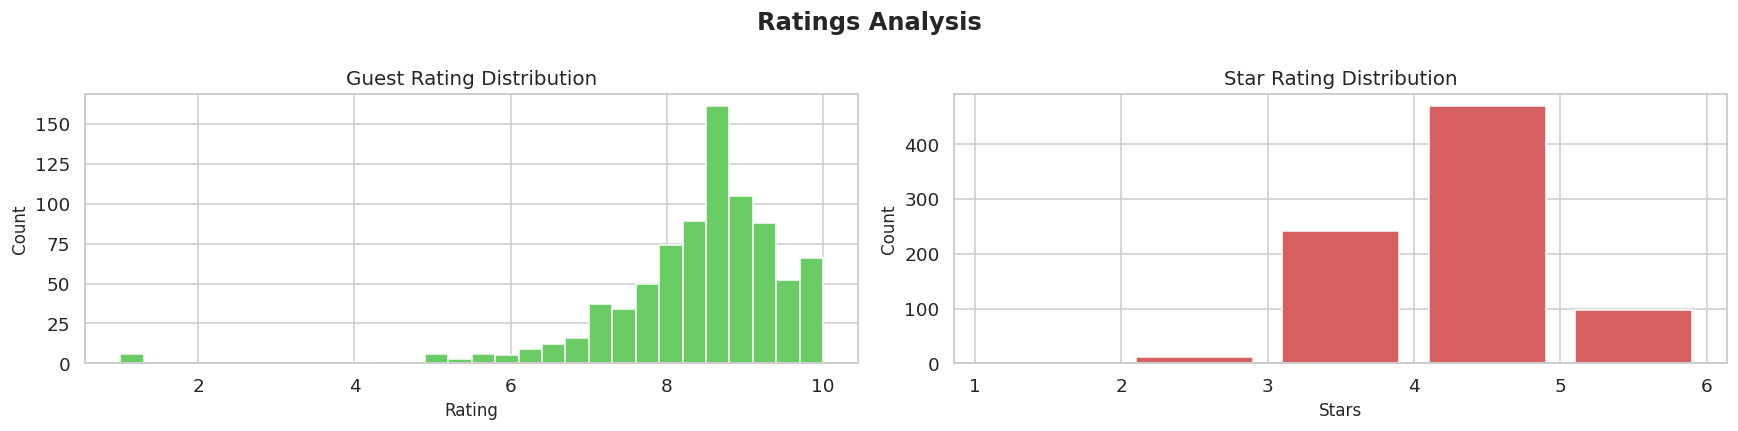

Average guest rating: 8.37 / 10
Average star rating:  3.8 stars


In [131]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Rating distribution
axes[0].hist(df['rating'], bins=30, color=PALETTE[2], edgecolor='white')
axes[0].set_title('Guest Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Star rating
axes[1].hist(df['star_rating'].dropna(), bins=[1,2,3,4,5,6], color=PALETTE[3],
             edgecolor='white', rwidth=0.8)
axes[1].set_title('Star Rating Distribution')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')


plt.suptitle('Ratings Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average guest rating: {df['rating'].mean():.2f} / 10")
print(f"Average star rating:  {df['star_rating'].mean():.1f} stars")

### 3.5 Price vs Star Rating

/tmp/ipykernel_3289/2716299345.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=star_med, x='star_rating', y='price', palette='YlOrRd',ax=ax)


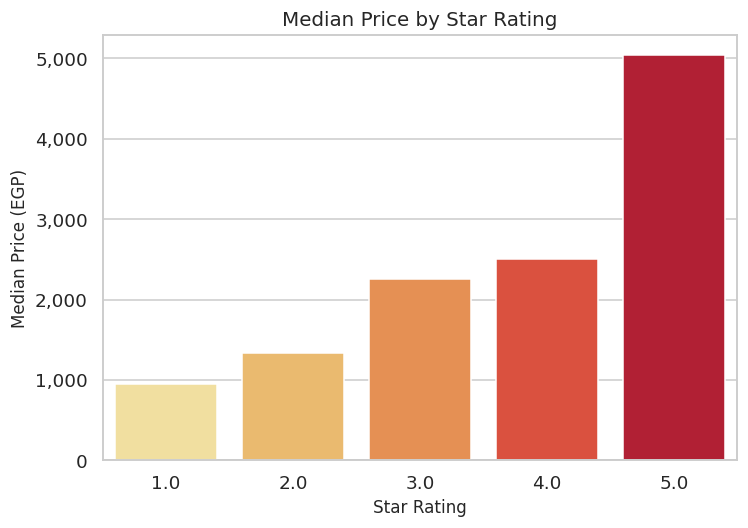

In [132]:
fig, ax = plt.subplots(figsize=(7, 5))

star_med = df.groupby('star_rating')['price'].median().reset_index()

sns.barplot( data=star_med, x='star_rating', y='price', palette='YlOrRd',ax=ax)

ax.set_title('Median Price by Star Rating')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Median Price (EGP)')

ax.yaxis.set_major_formatter( mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

> **Insight:** There is a clear step-wise increase in price from 2★ to 5★ properties. Five-star hotels have a median price roughly 4× that of two-star properties. The wide IQR at 4–5 stars reflects high variance in luxury pricing.

### 3.6  Amenity Adoption Rates & Price Impact

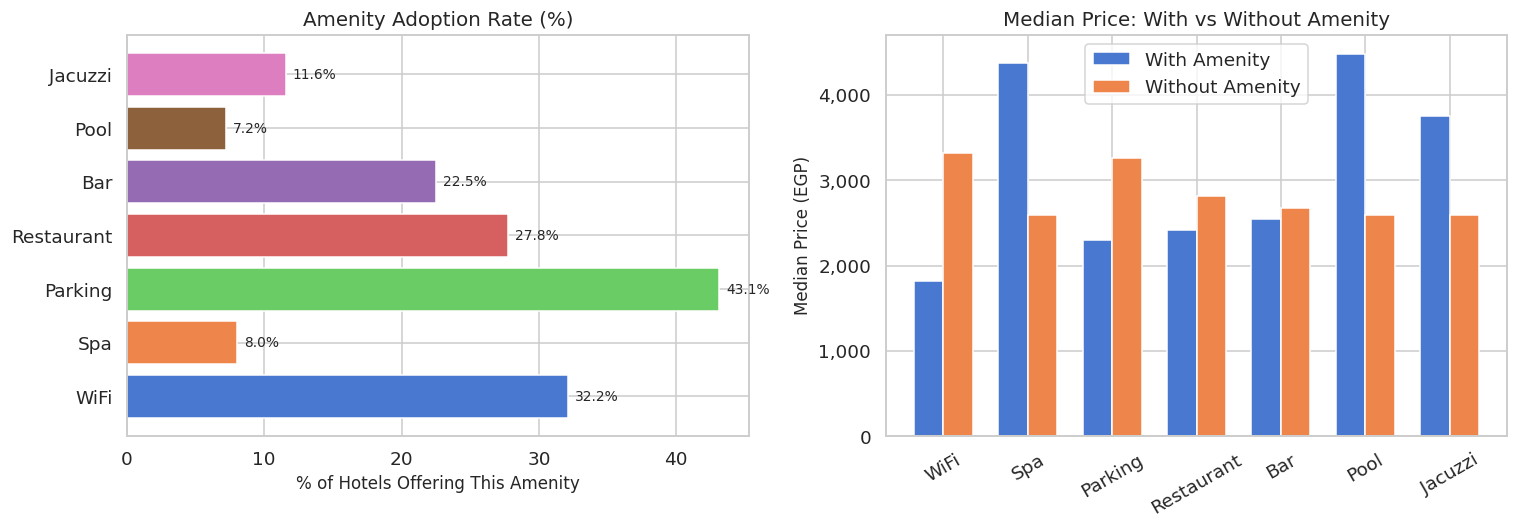

In [133]:
amenity_cols = ['has_wifi','has_spa','has_parking','has_restaurant',
                'has_bar','has_pool','has_jacuzzi']
labels = ['WiFi','Spa','Parking','Restaurant','Bar','Pool','Jacuzzi']

adoption = df[amenity_cols].mean() * 100
price_with = [df[df[c]==1]['price'].median() for c in amenity_cols]
price_without = [df[df[c]==0]['price'].median() for c in amenity_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(labels, adoption.values, color=PALETTE[:7])
axes[0].set_title('Amenity Adoption Rate (%)')
axes[0].set_xlabel('% of Hotels Offering This Amenity')
for i, v in enumerate(adoption.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, price_with,    w, label='With Amenity',    color=PALETTE[0])
axes[1].bar(x + w/2, price_without, w, label='Without Amenity', color=PALETTE[1])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30)
axes[1].set_title('Median Price: With vs Without Amenity')
axes[1].set_ylabel('Median Price (EGP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.show()

> **Insight:** Spa and Jacuzzi show the largest price premium — hotels offering these amenities have significantly higher median prices. Free Parking is the most common amenity but has the smallest price premium, suggesting it's offered across all tiers.

### 3.7 Meal Plan & Free Cancellation Impact

/tmp/ipykernel_3289/2428073181.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='meal_plan', y='price', order=meal_order,
/tmp/ipykernel_3289/2428073181.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='free_cancellation', y='price',
/tmp/ipykernel_3289/2428073181.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Free Cancellation (0)', 'Free Cancellation (1)'])


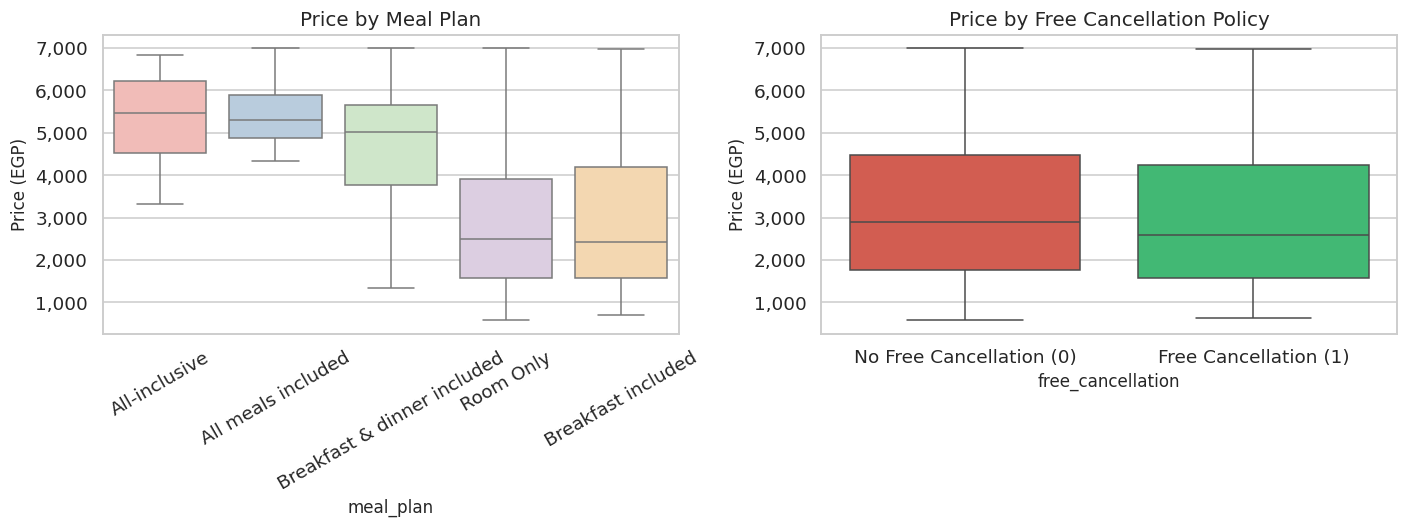

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

meal_order = df.groupby('meal_plan')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='meal_plan', y='price', order=meal_order,
            palette='Pastel1', ax=axes[0], showfliers=False)
axes[0].set_title('Price by Meal Plan')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Price (EGP)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.boxplot(data=df, x='free_cancellation', y='price',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1], showfliers=False)
axes[1].set_title('Price by Free Cancellation Policy')
axes[1].set_xticklabels(['No Free Cancellation (0)', 'Free Cancellation (1)'])
axes[1].set_ylabel('Price (EGP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

> **Insight:** Hotels offering full-board or half-board meal plans tend to be pricier — these are typically resort-style properties. Hotels with free cancellation have slightly higher median prices, suggesting premium properties use flexible policies to attract bookings.

## 4 Regression Modelling evaloation



### 4.1  Feature Preparation and spiltting the data

In [135]:

df_model = df.drop(columns=['hotel_name', 'location'])

X=df_model.drop(columns=['price'])
y=df_model['price']
categorical_cols = ['city', 'room_type', 'property_type', 'meal_plan']
numerical_cols   =['num_adults', 'num_children', 'num_nights', 'rating', 'reviews_count', 'distance_from_center', 'star_rating', 'free_cancellation', 'amenities_missing', 'has_wifi', 'has_spa', 'has_parking', 'has_restaurant', 'has_bar', 'has_pool', 'has_jacuzzi']

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
Xtr_num = pd.DataFrame(scaler.fit_transform(X_train[numerical_cols]), columns=numerical_cols, index=X_train.index)
Xte_num = pd.DataFrame(scaler.transform(X_test[numerical_cols]),  columns=numerical_cols, index=X_test.index)
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
Xtr_cat = pd.DataFrame(ohe.fit_transform(X_train[categorical_cols]),  columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)
Xte_cat = pd.DataFrame(ohe.transform(X_test[categorical_cols]),   columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)

Xtr = pd.concat([Xtr_num, Xtr_cat], axis=1)
Xte = pd.concat([Xte_num, Xte_cat], axis=1)


### 4.2 trainng models

#### 4.2.1 Linear Regression

In [137]:
# Linear Regression

lr_model = LinearRegression()
lr_model.fit(Xtr, y_train)
lr_pred_log = lr_model.predict(Xte)
lr_r2 = r2_score(y_test, lr_pred_log)

# Back-transform to EGP
lr_pred_egp = np.expm1(lr_pred_log)
y_test_egp = np.expm1(y_test)

lr_mae = mean_absolute_error(y_test_egp, lr_pred_egp)
lr_mse = mean_squared_error(y_test_egp, lr_pred_egp)
lr_rmse = np.sqrt(lr_mse)

print(f"Linear Regression")
print(f"R² Score : {lr_r2:.4f}")
print(f"MAE      : {lr_mae:,.0f} EGP")
print(f"RMSE     : {lr_rmse:,.0f} EGP")

Linear Regression
R² Score : 0.3793
MAE      : 1,091 EGP
RMSE     : 1,489 EGP


#### 4.2.2 Decision Tree Regressor

In [138]:
# Decision Tree Regressor

dt_model = DecisionTreeRegressor( max_depth=10, random_state=42)
dt_model.fit(Xtr, y_train)
dt_pred_log = dt_model.predict(Xte)
dt_r2 = r2_score(y_test, dt_pred_log)

# Back-transform to EGP
dt_pred_egp = np.expm1(dt_pred_log)

dt_mae = mean_absolute_error(y_test_egp, dt_pred_egp)
dt_mse = mean_squared_error(y_test_egp, dt_pred_egp)
dt_rmse = np.sqrt(dt_mse)

print(f"Decision Tree")
print(f"R² Score : {dt_r2:.4f}")
print(f"MAE      : {dt_mae:,.0f} EGP")
print(f"RMSE     : {dt_rmse:,.0f} EGP")

Decision Tree
R² Score : 0.2181
MAE      : 1,163 EGP
RMSE     : 1,550 EGP


#### 4.2.3 Decision Tree Regressor

In [139]:
# Random Forest Regressor

rf_model = RandomForestRegressor( n_estimators=200,random_state=42)
rf_model.fit(Xtr, y_train)
rf_pred_log = rf_model.predict(Xte)

rf_r2 = r2_score(y_test, rf_pred_log)

# Back-transform to EGP
rf_pred_egp = np.expm1(rf_pred_log)

rf_mae = mean_absolute_error(y_test_egp, rf_pred_egp)
rf_mse = mean_squared_error(y_test_egp, rf_pred_egp)
rf_rmse = np.sqrt(rf_mse)

print(f"Random Forest")
print(f"R² Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:,.0f} EGP")
print(f"RMSE     : {rf_rmse:,.0f} EGP")

Random Forest
R² Score : 0.4209
MAE      : 989 EGP
RMSE     : 1,296 EGP


#### 4.2.4 Ridge Regression

In [140]:
# Ridge Regression

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(Xtr, y_train)
ridge_pred_log = ridge_model.predict(Xte)

ridge_r2 = r2_score(y_test, ridge_pred_log)

# Back-transform to EGP
ridge_pred_egp = np.expm1(ridge_pred_log)

ridge_mae = mean_absolute_error(y_test_egp, ridge_pred_egp)
ridge_mse = mean_squared_error(y_test_egp, ridge_pred_egp)
ridge_rmse = np.sqrt(ridge_mse)

print(f"Ridge Regression")
print(f"R² Score : {ridge_r2:.4f}")
print(f"MAE      : {ridge_mae:,.0f} EGP")
print(f"RMSE     : {ridge_rmse:,.0f} EGP")

Ridge Regression
R² Score : 0.4599
MAE      : 975 EGP
RMSE     : 1,292 EGP


#### 4.2.5  Lasso Regression

In [141]:
# Lasso Regression

lasso_model = Lasso(alpha=0.001)
lasso_model.fit(Xtr, y_train)
lasso_pred_log = lasso_model.predict(Xte)

lasso_r2 = r2_score(y_test, lasso_pred_log)

# Back-transform to EGP
lasso_pred_egp = np.expm1(lasso_pred_log)

lasso_mae = mean_absolute_error(y_test_egp, lasso_pred_egp)
lasso_mse = mean_squared_error(y_test_egp, lasso_pred_egp)
lasso_rmse = np.sqrt(lasso_mse)

print(f"Lasso Regression")
print(f"R² Score : {lasso_r2:.4f}")
print(f"MAE      : {lasso_mae:,.0f} EGP")
print(f"RMSE     : {lasso_rmse:,.0f} EGP")

Lasso Regression
R² Score : 0.4793
MAE      : 933 EGP
RMSE     : 1,241 EGP


#### 4.2.6 Gradient Boosting Regressor

In [142]:
# Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(Xtr, y_train)
gb_pred_log = gb_model.predict(Xte)

gb_r2 = r2_score(y_test, gb_pred_log)

# Back-transform to EGP
gb_pred_egp = np.expm1(gb_pred_log)

gb_mae = mean_absolute_error(y_test_egp, gb_pred_egp)
gb_mse = mean_squared_error(y_test_egp, gb_pred_egp)
gb_rmse = np.sqrt(gb_mse)

print(f"Gradient Boosting")
print(f"R² Score : {gb_r2:.4f}")
print(f"MAE      : {gb_mae:,.0f} EGP")
print(f"RMSE     : {gb_rmse:,.0f} EGP")

Gradient Boosting
R² Score : 0.4424
MAE      : 948 EGP
RMSE     : 1,258 EGP


#### 4.2.7 XGBoost Regressor

In [143]:
# XGBoost Regressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)

xgb_model.fit(Xtr, y_train)
xgb_pred_log = xgb_model.predict(Xte)

xgb_r2 = r2_score(y_test, xgb_pred_log)

# Back-transform to EGP
xgb_pred_egp = np.expm1(xgb_pred_log)

xgb_mae = mean_absolute_error(y_test_egp, xgb_pred_egp)
xgb_mse = mean_squared_error(y_test_egp, xgb_pred_egp)
xgb_rmse = np.sqrt(xgb_mse)

print(f"XGBoost")
print(f"R² Score : {xgb_r2:.4f}")
print(f"MAE      : {xgb_mae:,.0f} EGP")
print(f"RMSE     : {xgb_rmse:,.0f} EGP")

XGBoost
R² Score : 0.4696
MAE      : 922 EGP
RMSE     : 1,219 EGP


### 4.3 Model Comparison Table

In [144]:
results_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'R²': [
        lr_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ],
    'MAE': [
        lr_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        xgb_mae
    ],
    'RMSE': [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse
    ]
})

results_df = results_df.round({'R²': 4, 'MAE': 0, 'RMSE': 0})
results_df['MAE'] = results_df['MAE'].map('{:,.0f}'.format)
results_df['RMSE'] = results_df['RMSE'].map('{:,.0f}'.format)

print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))


=== Model Comparison ===
            Model     R²   MAE  RMSE
Linear Regression 0.3793 1,091 1,489
 Ridge Regression 0.4599   975 1,292
 Lasso Regression 0.4793   933 1,241
    Decision Tree 0.2181 1,163 1,550
    Random Forest 0.4209   989 1,296
Gradient Boosting 0.4424   948 1,258
          XGBoost 0.4696   922 1,219


### 4.4 Visual Comparison — R² and MAE

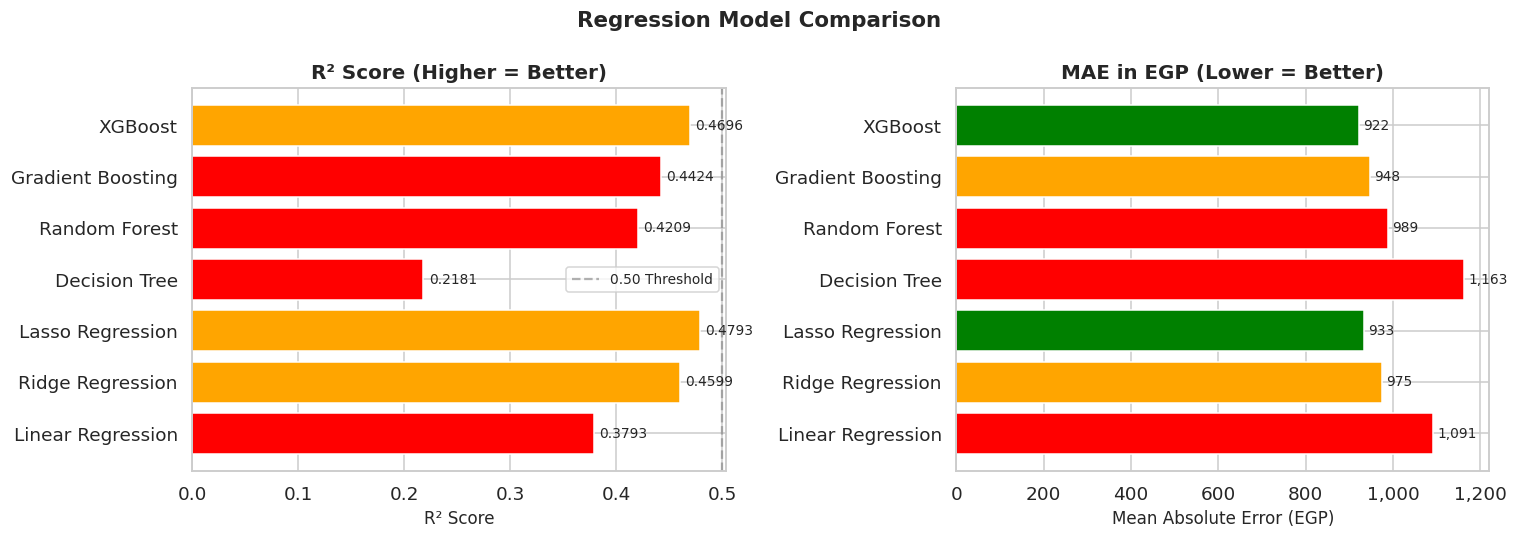

In [145]:
results_df['R²'] = pd.to_numeric(results_df['R²'])
results_df['MAE'] = results_df['MAE'].astype(str).str.replace(',', '').astype(float)

# Use model names as index
plot_df = results_df.set_index('Model')

colors = ['red' if v < 0.45 else 'orange' if v < 0.55 else 'green'
          for v in plot_df['R²']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Plot
axes[0].barh(plot_df.index, plot_df['R²'], color=colors)
axes[0].set_title('R² Score (Higher = Better)', fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].axvline(0.5, color='gray', linestyle='--',
                alpha=0.6, label='0.50 Threshold')
axes[0].legend(fontsize=9)

for i, v in enumerate(plot_df['R²']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# MAE Plot
# MAE Plot
mae_colors = [
    'green' if v <= plot_df['MAE'].quantile(0.33)
    else 'orange' if v <= plot_df['MAE'].quantile(0.66)
    else 'red'
    for v in plot_df['MAE']
]

axes[1].barh(plot_df.index, plot_df['MAE'], color=mae_colors)
axes[1].set_title('MAE in EGP (Lower = Better)', fontweight='bold')
axes[1].set_xlabel('Mean Absolute Error (EGP)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

for i, v in enumerate(plot_df['MAE']):
    axes[1].text(v + 10, i, f'{v:,.0f}', va='center', fontsize=9)

plt.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Predicted vs Actual — Best Model

Best model: Lasso Regression  (R² = 0.4793)


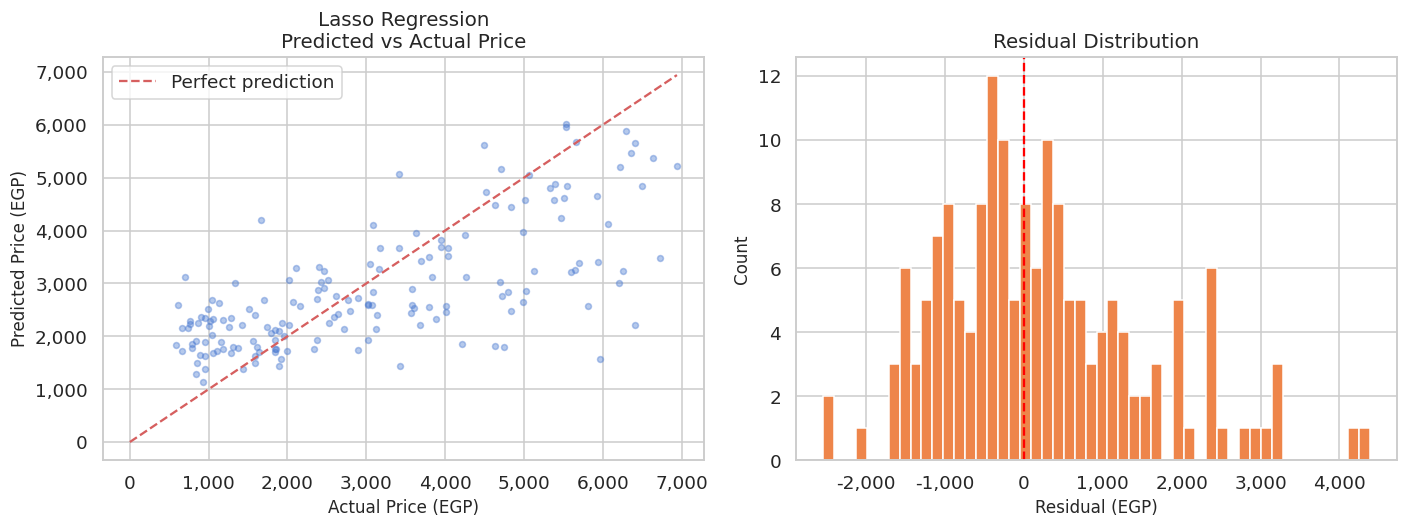

In [146]:
best_model_idx = results_df['R²'].idxmax()
best_name = results_df.loc[best_model_idx, 'Model']
best_r2_score = results_df.loc[best_model_idx, 'R²']

print(f"Best model: {best_name}  (R² = {best_r2_score:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test_egp, rf_pred_egp, alpha=0.4, s=15, color=PALETTE[0])
lim = max(y_test_egp.max(), rf_pred_egp.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_title(f'{best_name}\nPredicted vs Actual Price')
axes[0].set_xlabel('Actual Price (EGP)')
axes[0].set_ylabel('Predicted Price (EGP)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# Residuals
residuals = y_test_egp - rf_pred_egp
axes[1].hist(residuals, bins=50, color=PALETTE[1], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (EGP)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### 4.6 Feature Importance

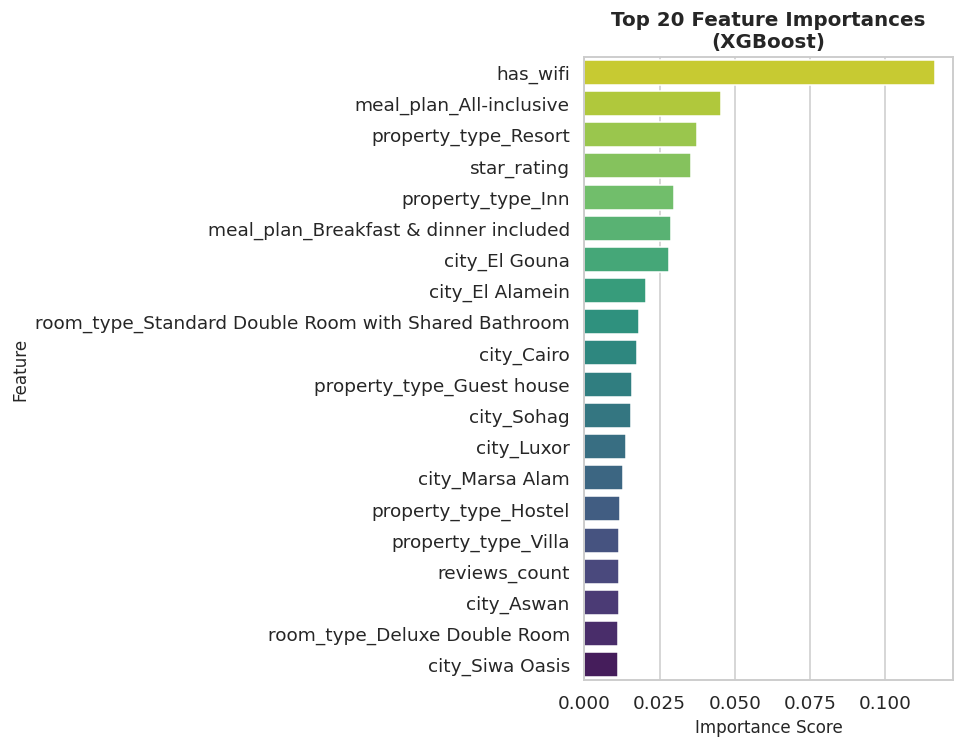

Top 10 most important features:
has_wifi                                               0.1167
meal_plan_All-inclusive                                0.0454
property_type_Resort                                   0.0375
star_rating                                            0.0356
property_type_Inn                                      0.0297
meal_plan_Breakfast & dinner included                  0.0288
city_El Gouna                                          0.0282
city_El Alamein                                        0.0206
room_type_Standard Double Room with Shared Bathroom    0.0183
city_Cairo                                             0.0174
dtype: object


In [147]:
# Tree-based models and their R² scores
tree_models = {
    'Decision Tree': (dt_model, dt_r2),
    'Random Forest': (rf_model, rf_r2),
    'Gradient Boosting': (gb_model, gb_r2),
    'XGBoost': (xgb_model, xgb_r2)
}

# Select best tree model based on R²
best_tree = max(tree_models, key=lambda k: tree_models[k][1])
best_tree_model = tree_models[best_tree][0]

# Feature importances
importances = pd.Series(
    best_tree_model.feature_importances_,
    index=Xtr.columns
).sort_values(ascending=False).head(20)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette='viridis_r',
    legend=False,
    ax=ax
)

ax.set_title(f'Top 20 Feature Importances\n({best_tree})', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importances.head(10).apply(lambda x: f"{x:.4f}"))

## 5 Database Integration — SQLite


### 5.1 Create Database & Insert Data

In [148]:
import sqlite3

db = sqlite3.connect("egypt_hotels.db")
cursor = db.cursor()
cursor.execute("""
CREATE TABLE IF NOT EXISTS hotels (
    city                 TEXT,
    hotel_name           TEXT,
    price                INTEGER,
    num_adults           INTEGER,
    num_children         INTEGER,
    num_nights           INTEGER,
    rating               REAL,
    reviews_count        INTEGER,
    location             TEXT,
    distance_from_center REAL,
    star_rating          REAL,
    property_type        TEXT,
    room_type            TEXT,
    free_cancellation    INTEGER,
    meal_plan            TEXT,
    amenities_missing    INTEGER,
    has_wifi             INTEGER,
    has_spa              INTEGER,
    has_parking          INTEGER,
    has_restaurant       INTEGER,
    has_bar              INTEGER,
    has_pool             INTEGER,
    has_jacuzzi          INTEGER
)
""")

data = df.values.tolist()

cursor.executemany("""
INSERT INTO hotels (
    city, hotel_name, price, num_adults, num_children,
    num_nights, rating, reviews_count, location,
    distance_from_center, star_rating, property_type,
    room_type, free_cancellation, meal_plan,
    amenities_missing, has_wifi, has_spa,
    has_parking, has_restaurant, has_bar,
    has_pool, has_jacuzzi
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
""", data)

db.commit()

print("Database created: egypt_hotels.db")
print("Data inserted successfully")


Database created: egypt_hotels.db
Data inserted successfully


### 5.2 SQL Queries

In [149]:
# Query 1
query1 = """
SELECT city, hotel_name, price
FROM hotels
ORDER BY price DESC
LIMIT 10
"""

print("=== Top 10 Most Expensive Hotels ===")
print(pd.read_sql(query1, db)) # read_sql => Executes SQL Queries, Returns Results and Converts Them Directly to DataFrames But excute => returns Cursor and needs fetch afterward


=== Top 10 Most Expensive Hotels ===
         city                                         hotel_name  price
0  Alexandria  Nabeel Homes - Seaview Building - 3 Units in S...   6992
1    Hurghada          Pickalbatros Aqua Vista Resort - Hurghada   6992
2  Alexandria  Nabeel Homes - Seaview Building - 3 Units in S...   6992
3    Hurghada          Pickalbatros Aqua Vista Resort - Hurghada   6992
4  Alexandria  Nabeel Homes - Seaview Building - 3 Units in S...   6992
5    Hurghada          Pickalbatros Aqua Vista Resort - Hurghada   6992
6  Ain Sokhna              Eastern El-Galala Aquapark Ain Sokhna   6991
7  Ain Sokhna              Eastern El-Galala Aquapark Ain Sokhna   6991
8  Ain Sokhna              Eastern El-Galala Aquapark Ain Sokhna   6991
9  Alexandria  Le Metropole Luxury Heritage Hotel Since 1902 ...   6978


In [150]:
# Query 2
query2 = """
SELECT city, AVG(price) AS avg_price
FROM hotels
GROUP BY city
ORDER BY avg_price DESC
"""

print("\n=== Average Price in Each City ===")
print(pd.read_sql(query2, db))


=== Average Price in Each City ===
               city    avg_price
0        El Alamein  4346.818182
1          El Gouna  4174.640000
2        Ain Sokhna  4030.266667
3          Hurghada  3915.600000
4   Sharm El Sheikh  3733.367347
5        Marsa Alam  3687.648148
6             Cairo  3378.421053
7        Alexandria  3233.538462
8          Al Minya  3226.615385
9            Fayoum  3073.107143
10           Assyut  2877.250000
11     Marsa Matruh  2768.017241
12            Dahab  2424.154930
13            Aswan  2172.154930
14       Siwa Oasis  1981.338028
15            Luxor  1971.606061
16            Sohag  1509.125000


In [151]:
# Query 3
query3 = """
SELECT city, hotel_name, rating
FROM hotels
WHERE rating > 8
"""

print("\n=== Hotels with Rating Above 8 ===")
print(pd.read_sql(query3, db))


=== Hotels with Rating Above 8 ===
          city                       hotel_name  rating
0        Cairo            Regant pyramids hotel    10.0
1        Cairo                       Sky-lounge     8.6
2        Cairo              gold cairo downtown     8.6
3        Cairo                    cairoooo houb     8.6
4        Cairo     Ramses Hilton Hotel & Casino     8.5
...        ...                              ...     ...
1732  Al Minya    Omar El Khayam Al Minya Hotel     9.3
1733  Al Minya  Village Room in the Countryside     8.6
1734  Al Minya                Countryside House     8.6
1735  Al Minya                Holy Family Hotel     8.5
1736  Al Minya                   Mori apartment     8.6

[1737 rows x 3 columns]


In [152]:
# Query 4
query4 = """
SELECT city, COUNT(*) AS total_hotels
FROM hotels
GROUP BY city
"""

print("\n=== Number of Hotels in Each City ===")
print(pd.read_sql(query4, db))


=== Number of Hotels in Each City ===
               city  total_hotels
0        Ain Sokhna           180
1          Al Minya            39
2        Alexandria           195
3            Assyut            36
4             Aswan           213
5             Cairo           171
6             Dahab           213
7        El Alamein            99
8          El Gouna           150
9            Fayoum            84
10         Hurghada           165
11            Luxor           198
12       Marsa Alam           162
13     Marsa Matruh           174
14  Sharm El Sheikh           147
15       Siwa Oasis           213
16            Sohag            24


In [153]:
# Query 5
query5 = """
SELECT city, hotel_name, property_type
FROM hotels
WHERE has_wifi = 1
"""

print("\n=== Hotels with WiFi ===")
print(pd.read_sql(query5, db))


=== Hotels with WiFi ===
           city                                         hotel_name  \
0         Cairo  Skyline luxury hotel apartments 5 mins from Ca...   
1         Cairo                         Horus Cairo Hotel Downtown   
2         Cairo                                   City Stars Hotel   
3         Cairo                        Pyramisa Suites Hotel Cairo   
4         Cairo                                         City Hotel   
..          ...                                                ...   
787  Ain Sokhna                           Porto Sokhna Hotel & Spa   
788  Ain Sokhna     3BR Cozy SeaView Chalet in Ein Bay l AinSokhna   
789  Ain Sokhna                          La Siesta Hotel Al Sokhna   
790  Ain Sokhna                        Porto Sokhna Pyramids Hotel   
791  Ain Sokhna               La Sirena Ain Sokhna Sea View Resort   

    property_type  
0       Apartment  
1           Hotel  
2           Hotel  
3           Hotel  
4           Hotel  
..           

In [154]:
# Query 6
query6 = """
SELECT property_type,
AVG(rating) AS avg_rating
FROM hotels
GROUP BY property_type
"""

print("\n=== Average Rating by Property Type ===")
print(pd.read_sql(query6, db))


=== Average Rating by Property Type ===
  property_type  avg_rating
0     Apartment    8.297209
1   Guest house    9.307692
2        Hostel    8.750000
3         Hotel    8.362779
4           Inn    8.293939
5        Resort    8.304673
6         Villa    8.308696


In [155]:
# Query 7
query7 = """
SELECT city, hotel_name,
distance_from_center
FROM hotels
WHERE distance_from_center < 1
"""

print("\n=== Hotels Near City Center ===")
print(pd.read_sql(query7, db))


=== Hotels Near City Center ===
         city                     hotel_name  distance_from_center
0       Cairo            gold cairo downtown                  0.10
1       Cairo                  cairoooo houb                  0.20
2       Cairo   Ramses Hilton Hotel & Casino                  0.70
3       Cairo     Horus Cairo Hotel Downtown                  0.30
4       Cairo               City Stars Hotel                  0.10
..        ...                            ...                   ...
421    Assyut            فندق الحسين السياحي                  0.25
422  Al Minya            Savoy Hotel ELMinya                  0.30
423  Al Minya                Akhenaton Hotel                  0.35
424  Al Minya  Omar El Khayam Al Minya Hotel                  0.25
425  Al Minya                   The Red Palm                  0.15

[426 rows x 3 columns]


In [157]:
# Query 8
query8 = """
SELECT COUNT(*) AS hotels_with_pool
FROM hotels
WHERE has_pool = 1
"""

print("\n=== Number of Hotels with Pool ===")
print(pd.read_sql(query8, db))


=== Number of Hotels with Pool ===
   hotels_with_pool
0               177


In [158]:
# Query 9
query9 = """
SELECT city,
AVG(rating) AS avg_rating
FROM hotels
GROUP BY city
ORDER BY avg_rating DESC
LIMIT 1
"""

print("\n=== City with Highest Average Rating ===")
print(pd.read_sql(query9, db))


=== City with Highest Average Rating ===
         city  avg_rating
0  Siwa Oasis    8.997183


In [159]:
# Query 10
query10 = """
SELECT city
FROM hotels
WHERE has_restaurant = 1
AND has_bar = 1
"""

print("\n=== Hotels with Restaurant and Bar ===")
print(pd.read_sql(query10, db))


=== Hotels with Restaurant and Bar ===
           city
0         Cairo
1         Cairo
2         Cairo
3         Cairo
4         Cairo
..          ...
295  Ain Sokhna
296  Ain Sokhna
297  Ain Sokhna
298  Ain Sokhna
299  Ain Sokhna

[300 rows x 1 columns]
